# 03. Modeling
`src/train.py` 실행 결과를 확인한다.
- 학습 B1 (충전 정책 단위 5-fold 튜닝, fold 고정) → 평가 B2 (1차), B3 (2차)
- 지표 : MAPE(주) · MAE · RMSE, GAP = B2 MAPE − 논문 9.1 (%p)

In [1]:
import os, sys
sys.path.append(os.path.abspath('../src')); os.chdir('..')
import pandas as pd
from train import run
res = run('data/features.csv', 'results')
pd.set_option('display.width', 200)

train B1 n=36, policies=20, life range 534~1074


## 1. 성능 요약 (MAPE %)

In [2]:
t = res.pivot_table(index=['feature_set','model'], columns='split', values='MAPE')[['CV_B1','B2','B3']]
t['GAP_B2_vs_paper(%p)'] = t['B2'] - 9.1
t.round(1)

split                         CV_B1    B2    B3  GAP_B2_vs_paper(%p)
feature_set     model                                               
A_dq_var        Dummy          16.3  59.1  22.7                 50.0
                ElasticNet      9.0  28.6  11.7                 19.5
                GBM             9.2  30.8  14.2                 21.7
                RandomForest    9.0  30.2  15.5                 21.1
                Ridge           9.0  28.6  11.7                 19.5
B_dq_var+fade   Dummy          16.3  59.1  22.7                 50.0
                ElasticNet      9.3  30.2  11.6                 21.1
                GBM             9.3  25.9  14.5                 16.8
                RandomForest    8.7  30.4  15.4                 21.3
                Ridge          10.4  40.4  13.0                 31.3
C_dq_min        Dummy          16.3  59.1  22.7                 50.0
                ElasticNet      9.5  30.5  11.8                 21.4
                GBM            10.9  31.1  17.4                 22.0
                RandomForest   10.3  30.6  15.7                 21.5
                Ridge           9.5  31.1  11.8                 22.0
D_with_excluded Dummy          16.3  59.1  22.7                 50.0
                ElasticNet      7.0  43.6  12.8                 34.5
                GBM             9.3  39.4  15.4                 30.3
                RandomForest    9.1  33.1  15.6                 24.0
                Ridge           8.2  43.9  16.1                 34.8

## 2. 기본 피처(A) 상세 지표

In [3]:
res[res.feature_set=='A_dq_var'][['model','split','MAPE','MAE','RMSE','n','params']].round(1)

,model,split,MAPE,MAE,RMSE,n,params
0,Dummy,CV_B1,16.3,126.8,149.8,36,{'m__strategy': 'mean'}
1,Dummy,B2,59.1,286.1,303.1,39,{'m__strategy': 'mean'}
2,Dummy,B3,22.7,276.5,398.7,40,{'m__strategy': 'mean'}
3,ElasticNet,CV_B1,9.0,72.8,90.4,36,"{'m__alpha': 0.0001, 'm__l1_ratio': 0.1}"
4,ElasticNet,B2,28.6,143.6,163.1,39,"{'m__alpha': 0.0001, 'm__l1_ratio': 0.1}"
5,ElasticNet,B3,11.7,133.2,209.2,40,"{'m__alpha': 0.0001, 'm__l1_ratio': 0.1}"
6,Ridge,CV_B1,9.0,72.8,90.4,36,{'m__alpha': 0.1}
7,Ridge,B2,28.6,143.8,163.2,39,{'m__alpha': 0.1}
8,Ridge,B3,11.7,133.2,209.5,40,{'m__alpha': 0.1}
9,RandomForest,CV_B1,9.0,72.1,92.1,36,"{'m__max_depth': 2, 'm__min_samples_leaf': 3}"


## 3. 외삽 점검 : 학습 수명 범위(534~1,074) 안 / 밖

In [4]:
e = pd.read_csv('results/extrapolation.csv')
e[e.feature_set=='A_dq_var'].pivot_table(index=['split','range'], columns='model', values='MAPE').round(1)

model                Dummy  ElasticNet   GBM  RandomForest  Ridge
split range                                                      
B2    inside          10.8        21.0  12.7          13.0   20.9
      outside_above   33.3         5.3  14.7          18.1    5.3
      outside_below   72.1        31.9  36.0          35.0   32.0
B3    inside          14.1        10.4   9.2          10.0   10.4
      outside_above   40.6        14.6  24.5          26.9   14.6

## 4. 예측 vs 실제, B1 관계의 연장

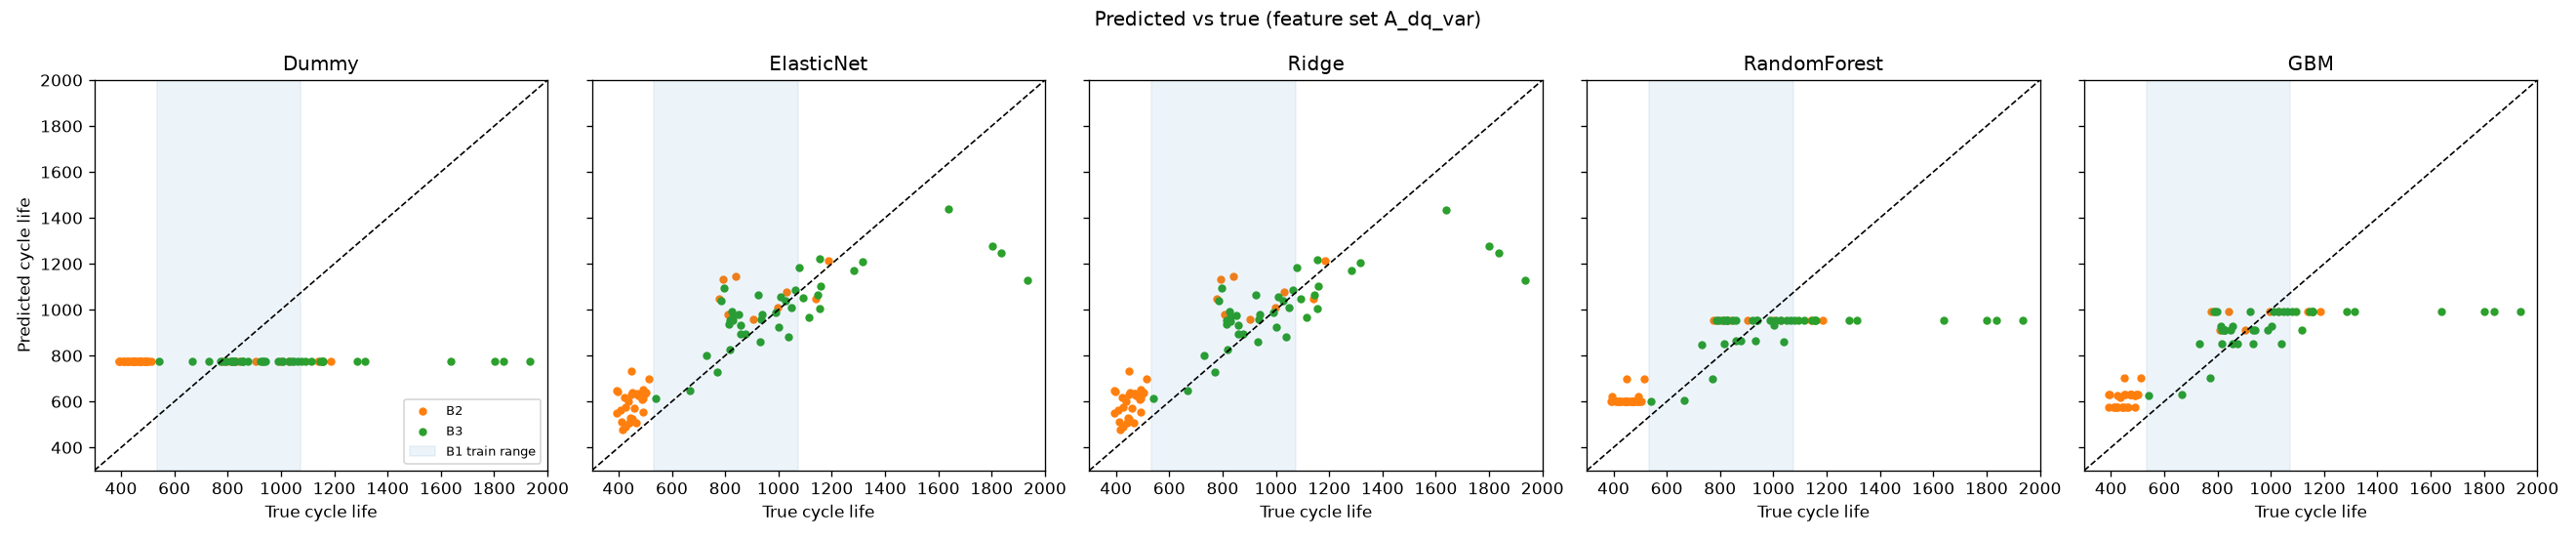

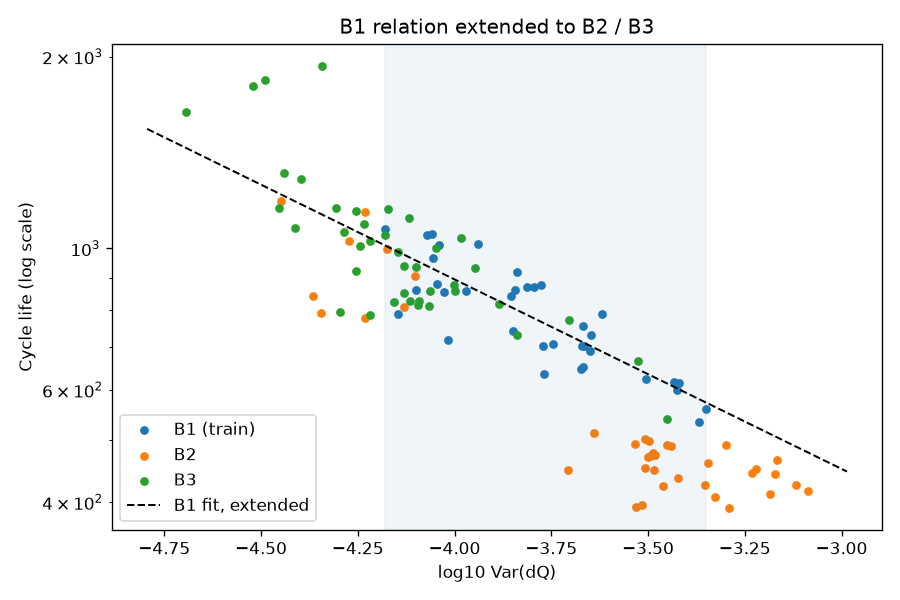

In [5]:
from IPython.display import Image, display
display(Image('results/pred_vs_true.png')); display(Image('results/relation_extended.png'))

## 5. 오류 분석 : 가장 크게 틀린 셀 (ElasticNet, 세트 A)

In [6]:
p = pd.read_csv('results/predictions.csv')
a = p[(p.feature_set=='A_dq_var') & (p.model=='ElasticNet')].copy()
a['err'] = a['pred'] - a['true']
print(a.groupby('split')['err'].agg(['mean','median']).round(0))
a.sort_values('ape(%)', ascending=False).head(10)[['split','cell_id','policy','true','pred','ape(%)']]

        mean  median
split               
B2     139.0   153.0
B3     -28.0    15.0


,split,cell_id,policy,true,pred,ape(%)
85,B2,b2c6,3.6C(9%)-5C,393.0,648.22,64.94
97,B2,b2c18,5.2C(50%)-4.25C,449.0,731.82,62.99
94,B2,b2c15,3.6C(9%)-5C,396.0,642.13,62.16
81,B2,b2c2,5.2C(50%)-4.25C,424.0,617.99,45.75
88,B2,b2c9,5.6C(26%)-4.5C-newstructure,791.0,1131.72,43.08
152,B3,b3c38,5C(67%)-4C-newstructure,1935.0,1129.89,41.61
106,B2,b2c29,5.2C(58%)-4C,452.0,638.63,41.29
98,B2,b2c19,6C(60%)-3C,392.0,550.77,40.50
90,B2,b2c11,5.2C(50%)-4.25C,449.0,628.72,40.03
100,B2,b2c21,6C(60%)-3C,408.0,564.01,38.24
